# 02 — MG95 Price Forecasting: model families + News Sentiment

**Objective:** Test on the new data (`clean_data_exo_ver1.csv`) + news sentiment, comparing model groups on 4 metrics **MAE, MAPE, SMAPE, R2** (also keeping RMSE).

**Models:**
- Statistical: **SARIMA**, **ARIMAX** (one-step-ahead, statsmodels)
- Linear: **Ridge/Linear Regression** (continuous baseline)
- Direction classification: **Logistic Regression** (predict up/down — report Accuracy/F1)
- Tree: **LightGBM**
- Deep Learning: **LSTM** (Keras), **PatchTST** & **TFT** (PyTorch / neuralforecast)

**News:** the notebook auto left-joins `news-crawler/data/daily_features.csv` by date (0-fill) if present; if absent it is skipped without error.

--- All models are evaluated **one-step-ahead (H=1)** on the same test window for a fair comparison. Change `HORIZON` in CONFIG to run other horizons. ---

(Added model **Jump-Gated ARIMAX-CatBoost**: a hybrid using ARIMAX + CatBoost with a layer that flags large-jump days.)

In [1]:
%pip install -r ../requirements.txt

     ---------------------------------------- 0.0/57.4 kB ? eta -:--:--
     ---------------------------------------- 57.4/57.4 kB 3.1 MB/s eta 0:00:00
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
    --------------------------------------- 0.2/8.3 MB 5.1 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 6.1 MB/s eta 0:00:02
   --------- ------------------------------ 1.9/8.3 MB 13.4 MB/s eta 0:00:01
   --------------- ------------------------ 3.2/8.3 MB 16.8 MB/s eta 0:00


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")   # repo models use Keras-2 API (TF 2.17 ships Keras 3)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

# === Setup ===
import warnings; warnings.filterwarnings("ignore")
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# Cai dat (chay 1 lan neu thieu thu vien):
# pip install lightgbm statsmodels scikit-learn tensorflow catboost
# pip install neuralforecast   # PatchTST + TFT (pulls in torch + lightning)

CONFIG = {
    "target":      "MG95",
    "horizon":     1,            # one-step-ahead
    "seq_len":     30,           # do dai chuoi cho LSTM / PatchTST / TFT
    "train_ratio": 0.80,
    "val_ratio":   0.10,
    "exog_cols":   ["WTI", "USD_Index", "GPR", "BRT DTD", "Brent_EU_Daily"],
    "seasonal":    5,            # chu ky tuan giao dich (5 ngay)
    "lstm_epochs": 40,
    "nf_steps":    300,          # max_steps cho PatchTST/TFT (tang de chinh xac hon)
    "tune_lgbm":   False,        # True = chay Optuna (cham hon)
}
print("ROOT =", ROOT)
print("CONFIG =", CONFIG)

ROOT = d:\oil\Oil-forcasting
CONFIG = {'target': 'MG95', 'horizon': 1, 'seq_len': 30, 'train_ratio': 0.8, 'val_ratio': 0.1, 'exog_cols': ['WTI', 'USD_Index', 'GPR', 'BRT DTD', 'Brent_EU_Daily'], 'seasonal': 5, 'lstm_epochs': 40, 'nf_steps': 300, 'tune_lgbm': False}


## 1. Load exogenous data + (optional) News

In [3]:
from src.data_loader import load_and_engineer

TARGET = CONFIG["target"]
df = load_and_engineer()          # doc data/processed/clean_data_exo_ver1.csv + feature engineering
print("Exo data:", df.shape, "|", df.index.min().date(), "->", df.index.max().date())

# --- News join (tuy chon, auto-skip neu thieu) ---
news_path = ROOT / "news-crawler" / "data" / "daily_features.csv"
news_cols = []
if news_path.exists():
    news = pd.read_csv(news_path, parse_dates=["date"]).set_index("date")
    news = news[~news.index.duplicated(keep="last")].sort_index()
    df = df.join(news, how="left")
    news_cols = list(news.columns)
    df[news_cols] = df[news_cols].fillna(0.0)   # days with no news -> 0
    cov = (df[news_cols].abs().sum(axis=1) > 0).mean() * 100
    print(f"News joined: +{len(news_cols)} cot | phu song ~{cov:.1f}% so ngay (con lai = 0)")
else:
    print("daily_features.csv not found -> running without news.")
    print("Tao bang: news-crawler -> crawl -> sentiment.py -> aggregate.py")
df.tail(3)

Exo data: (4619, 52) | 2008-06-12 -> 2026-05-08
News joined: +16 cot | phu song ~87.7% so ngay (con lai = 0)


,MG97,MG95,MG92,NAPHTHA,KERO,DO 0.001%,DO 0.05%,FO 180,BRT DTD,BRT KH,...,political_economy_sent_sum,political_economy_intensity,natural_disaster_n,natural_disaster_sent_mean,natural_disaster_sent_sum,natural_disaster_intensity,all_n,all_sent_mean,all_sent_sum,all_intensity
Ngày,,,,,,,,,,,,,,,,,,,,,
2026-05-06,133.22,134.40,133.34,129.12,200.54,157.04,146.90,662.85,117.485,109.05,...,0.0,0.0,0,0.0,0.0,0.0,2,0.1500,0.3,0.3
2026-05-07,133.22,127.53,126.14,129.12,200.54,149.29,138.77,662.85,117.485,109.05,...,0.0,0.0,0,0.0,0.0,0.0,5,-0.0600,-0.3,2.1
2026-05-08,133.22,126.06,124.48,129.12,200.54,153.97,142.95,662.85,117.485,109.05,...,-1.1,1.1,0,0.0,0.0,0.0,7,-0.3857,-2.7,2.7


## 2. Evaluation metrics — MAE, RMSE, MAPE, SMAPE, R2 (+ classification)

In [4]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score)

def reg_metrics(y_true, y_pred, name):
    yt = np.asarray(y_true, float); yp = np.asarray(y_pred, float)
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mape = np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-8))) * 100
    smape = np.mean(2.0 * np.abs(yp - yt) / (np.abs(yt) + np.abs(yp) + 1e-8)) * 100
    return {"Model": name, "MAE": round(mae,4), "RMSE": round(rmse,4),
            "MAPE(%)": round(mape,4), "SMAPE(%)": round(smape,4),
            "R2": round(r2_score(yt, yp),4)}

def clf_metrics(y_true, y_pred, name):
    return {"Model": name,
            "Accuracy": round(accuracy_score(y_true, y_pred),4),
            "F1": round(f1_score(y_true, y_pred, zero_division=0),4)}

results = []        # regression models
clf_results = []    # logistic (direction classification)
print("Metrics ready.")

Metrics ready.


## 3. Data preparation — chronological split (no leakage) + scaling

RobustScaler fit **on train only**. Split chronologically, not random.

In [5]:
from sklearn.preprocessing import RobustScaler

H = CONFIG["horizon"]
feature_cols = [c for c in df.columns if c != TARGET]

work = df.copy()
work["__y"] = work[TARGET].shift(-H)     # target = gia MG95 tai t+H
work = work.dropna(subset=["__y"])

n   = len(work)
ntr = int(n * CONFIG["train_ratio"])
nvl = int(n * CONFIG["val_ratio"])
tr, vl, te = work.iloc[:ntr], work.iloc[ntr:ntr+nvl], work.iloc[ntr+nvl:]

scaler_X = RobustScaler().fit(tr[feature_cols])
Xtr = scaler_X.transform(tr[feature_cols])
Xvl = scaler_X.transform(vl[feature_cols])
Xte = scaler_X.transform(te[feature_cols])
ytr, yvl, yte = tr["__y"].values, vl["__y"].values, te["__y"].values
test_dates = te.index

# up/down direction labels for Logistic
dir_tr = (tr["__y"].values > tr[TARGET].values).astype(int)
dir_te = (te["__y"].values > te[TARGET].values).astype(int)

print(f"Features: {len(feature_cols)} (news: {len(news_cols)})")
print(f"Train {len(tr)} | Val {len(vl)} | Test {len(te)}")
print(f"Test period: {test_dates.min().date()} -> {test_dates.max().date()}")
print(f"Test up-rate (baseline cho Logistic): {dir_te.mean():.3f}")

Features: 67 (news: 16)
Train 3694 | Val 461 | Test 463
Test period: 2024-07-24 -> 2026-05-07
Test up-rate (baseline cho Logistic): 0.544


## 4. Statistical models — ARIMAX & SARIMA (one-step-ahead)

Fit on train, evaluate one-step-ahead on test via `append(refit=False)` — fair vs the H=1 models.

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_cols = [c for c in CONFIG["exog_cols"] if c in df.columns]
y_full  = df[TARGET].reset_index(drop=True).astype(float)
ex_full = df[exog_cols].reset_index(drop=True).astype(float)
N = len(y_full); n_test = len(te); split = N - n_test
y_te_arima = y_full.iloc[split:].values

# --- ARIMAX (co exog) ---
try:
    res = SARIMAX(y_full.iloc[:split], exog=ex_full.iloc[:split], order=(2,1,2),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
    res2 = res.append(y_full.iloc[split:], exog=ex_full.iloc[split:], refit=False)
    pred_ax = res2.predict(start=split, end=N-1, exog=ex_full.iloc[split:]).values
    results.append(reg_metrics(y_te_arima, pred_ax, "ARIMAX"))
    print("ARIMAX:", results[-1])
except Exception as e:
    print("ARIMAX skipped:", e)

# --- SARIMA (seasonal, no exog) ---
try:
    res_s = SARIMAX(y_full.iloc[:split], order=(1,1,1),
                    seasonal_order=(1,0,1,CONFIG["seasonal"]),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
    res_s2 = res_s.append(y_full.iloc[split:], refit=False)
    pred_sa = res_s2.predict(start=split, end=N-1).values
    results.append(reg_metrics(y_te_arima, pred_sa, "SARIMA"))
    print("SARIMA:", results[-1])
except Exception as e:
    print("SARIMA skipped:", e)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMAX: {'Model': 'ARIMAX', 'MAE': 1.4311, 'RMSE': np.float64(2.8239), 'MAPE(%)': np.float64(1.4614), 'SMAPE(%)': np.float64(1.4596), 'R2': 0.975}
SARIMA: {'Model': 'SARIMA', 'MAE': 1.5088, 'RMSE': np.float64(3.0465), 'MAPE(%)': np.float64(1.552), 'SMAPE(%)': np.float64(1.5508), 'R2': 0.9709}


## 5. Jump-Gated ARIMAX-CatBoost

New hybrid model: ARIMAX forecasts the baseline, CatBoost corrects the error, then a gate flags days with a likely large price jump. Results are appended to the comparison table below.

In [7]:
try:
    from src.models.jump_gated_arimax_catboost import (
        JumpGatedConfig,
        run_jump_gated_arimax_catboost,
    )

    jump_cfg = JumpGatedConfig(
        target=TARGET,
        horizon=H,
        train_ratio=CONFIG["train_ratio"],
        val_ratio=CONFIG["val_ratio"],
        exog_cols=CONFIG["exog_cols"],
        arimax_order=(2, 1, 2),
    )
    jump_result = run_jump_gated_arimax_catboost(
        load_and_engineer(target_col=TARGET),
        root=ROOT,
        config=jump_cfg,
        progress=True,
    )
    jump_row = jump_result["metrics"].query('Model == "Jump-Gated ARIMAX-CatBoost"').iloc[0].to_dict()
    results.append({k: jump_row[k] for k in ["Model", "MAE", "RMSE", "MAPE(%)", "SMAPE(%)", "R2"]})
    print("Jump-Gated ARIMAX-CatBoost:", results[-1])
except Exception as e:
    jump_result = None
    print("Jump-Gated ARIMAX-CatBoost skipped:", repr(e))

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


OOF fold 1: 2017-04-25 -> 2018-10-03 | MAE=0.7152
OOF fold 2: 2018-10-04 -> 2020-03-19 | MAE=1.1116
OOF fold 3: 2020-03-20 -> 2021-09-01 | MAE=1.0247
OOF fold 4: 2021-09-02 -> 2023-02-10 | MAE=2.1791


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


OOF fold 5: 2023-02-13 -> 2024-07-24 | MAE=1.2504
Jump-Gated ARIMAX-CatBoost MAE=1.2571
Jump-Gated ARIMAX-CatBoost: {'Model': 'Jump-Gated ARIMAX-CatBoost', 'MAE': 1.2571, 'RMSE': 2.6541, 'MAPE(%)': 1.2615, 'SMAPE(%)': 1.2603, 'R2': 0.9779}


## 5. Linear baseline — Ridge / Linear Regression

In [8]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0).fit(Xtr, ytr)
results.append(reg_metrics(yte, ridge.predict(Xte), "Ridge (Linear)"))
print(results[-1])

{'Model': 'Ridge (Linear)', 'MAE': 1.5451, 'RMSE': np.float64(3.0974), 'MAPE(%)': np.float64(1.508), 'SMAPE(%)': np.float64(1.5226), 'R2': 0.9699}


## 6. Logistic Regression — direction classification (up/down)

This is a **classification** task, reporting Accuracy / F1 (not MAPE/R2).

In [9]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, dir_tr)
clf_results.append(clf_metrics(dir_te, clf.predict(Xte), "LogisticRegression (direction)"))
print(clf_results[-1], "| baseline up-rate =", round(dir_te.mean(),3))

{'Model': 'LogisticRegression (huong)', 'Accuracy': 0.6242, 'F1': 0.5877} | baseline up-rate = 0.544


## 7. LightGBM

In [10]:
import lightgbm as lgb
if CONFIG["tune_lgbm"]:
    from src.models.baseline_lgbm import tune_lgbm, train_lgbm
    bp = tune_lgbm(Xtr, ytr, Xvl, yvl, n_trials=40)["best_params"]
    lgbm = train_lgbm(Xtr, ytr, Xvl, yvl, bp)
else:
    lgbm = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, max_depth=7,
                             num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                             min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1)
    lgbm.fit(Xtr, ytr, eval_set=[(Xvl, yvl)],
             callbacks=[lgb.early_stopping(50, verbose=False)])
results.append(reg_metrics(yte, lgbm.predict(Xte), "LightGBM"))
print(results[-1])

{'Model': 'LightGBM', 'MAE': 2.2288, 'RMSE': np.float64(4.3114), 'MAPE(%)': np.float64(2.2007), 'SMAPE(%)': np.float64(2.2508), 'R2': 0.9416}


## 8. LSTM (Keras)

Use the sliding window `make_windows` from `src.data_loader`. Auto-skip if TensorFlow is missing.

In [11]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    from src.data_loader import make_windows

    SEQ = CONFIG["seq_len"]
    n_df = len(df); ntr_df = int(n_df * CONFIG["train_ratio"])
    sy = RobustScaler().fit(df[[TARGET]].iloc[:ntr_df])      # scale y tren train
    Xall = scaler_X.transform(df[feature_cols].values)
    yall = sy.transform(df[[TARGET]].values).flatten()

    Xw, yw = make_windows(Xall, yall, time_steps=SEQ, horizon=H)
    nW = len(Xw); a = int(nW*0.8); b = int(nW*0.1)
    Xw_tr, Xw_vl, Xw_te = Xw[:a], Xw[a:a+b], Xw[a+b:]
    yw_tr, yw_vl, yw_te = yw[:a], yw[a:a+b], yw[a+b:]

    tf.random.set_seed(42); tf.keras.backend.clear_session()
    inp = layers.Input((SEQ, len(feature_cols)))
    x = layers.LSTM(64, return_sequences=True)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1)(x)
    lstm = Model(inp, out); lstm.compile(optimizer="adam", loss="mse")
    es = tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    lstm.fit(Xw_tr, yw_tr, validation_data=(Xw_vl, yw_vl),
             epochs=CONFIG["lstm_epochs"], batch_size=64, callbacks=[es], verbose=0)

    pred = sy.inverse_transform(lstm.predict(Xw_te, verbose=0)).flatten()
    ytru = sy.inverse_transform(yw_te.reshape(-1,1)).flatten()
    results.append(reg_metrics(ytru, pred, "LSTM"))
    print(results[-1])
except Exception as e:
    print("LSTM skipped:", repr(e))


{'Model': 'LSTM', 'MAE': 4.3822, 'RMSE': np.float64(8.2927), 'MAPE(%)': np.float64(4.2708), 'SMAPE(%)': np.float64(4.4194), 'R2': 0.7853}


## 9. PatchTST & TFT (PyTorch / neuralforecast)

One-step-ahead via `cross_validation` (h=1, step_size=1). Auto-skip if `neuralforecast` is missing.

--- neuralforecast needs a regular frequency. Oil price data has non-trading days, so the notebook resamples to business-day (`B`) and ffills to avoid errors. Increase `CONFIG['nf_steps']` for higher accuracy. ---

In [12]:
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import PatchTST, TFT

    nf_exog = [c for c in CONFIG["exog_cols"] if c in df.columns]
    base = df[[TARGET] + nf_exog].copy()
    base = base.asfreq("B").ffill()          # tan suat deu (business day)
    long = base.reset_index()
    long.columns = ["ds"] + [TARGET] + nf_exog
    long["unique_id"] = "MG95"
    long["y"] = long[TARGET]
    long = long[["unique_id", "ds", "y"] + nf_exog]

    n_test = min(len(te), 250)               # gioi han so window cho nhanh
    common = dict(h=H, input_size=CONFIG["seq_len"], max_steps=CONFIG["nf_steps"],
                  scaler_type="robust", hist_exog_list=nf_exog, enable_progress_bar=False)
    nf = NeuralForecast(models=[PatchTST(**common), TFT(**common)], freq="B")
    cv = nf.cross_validation(df=long, n_windows=n_test, step_size=1)

    for mname in ["PatchTST", "TFT"]:
        if mname in cv.columns:
            sub = cv.dropna(subset=[mname])
            results.append(reg_metrics(sub["y"].values, sub[mname].values, mname))
            print(results[-1])
except Exception as e:
    print("PatchTST/TFT skipped (can: pip install neuralforecast):", repr(e))

PatchTST/TFT skipped (can: pip install neuralforecast): ModuleNotFoundError("No module named 'neuralforecast'")


## 10. Results comparison + chart

=== Regression (test: 2024-07-24 -> 2026-05-07 ) ===


,MAE,RMSE,MAPE(%),SMAPE(%),R2
Model,,,,,
Jump-Gated ARIMAX-CatBoost,1.2571,2.6541,1.2615,1.2603,0.9779
ARIMAX,1.4311,2.8239,1.4614,1.4596,0.9750
Ridge (Linear),1.5451,3.0974,1.5080,1.5226,0.9699
SARIMA,1.5088,3.0465,1.5520,1.5508,0.9709
LightGBM,2.2288,4.3114,2.2007,2.2508,0.9416
LSTM,4.3822,8.2927,4.2708,4.4194,0.7853



=== Logistic (phan loai huong) ===


,Accuracy,F1
Model,,
LogisticRegression (huong),0.6242,0.5877


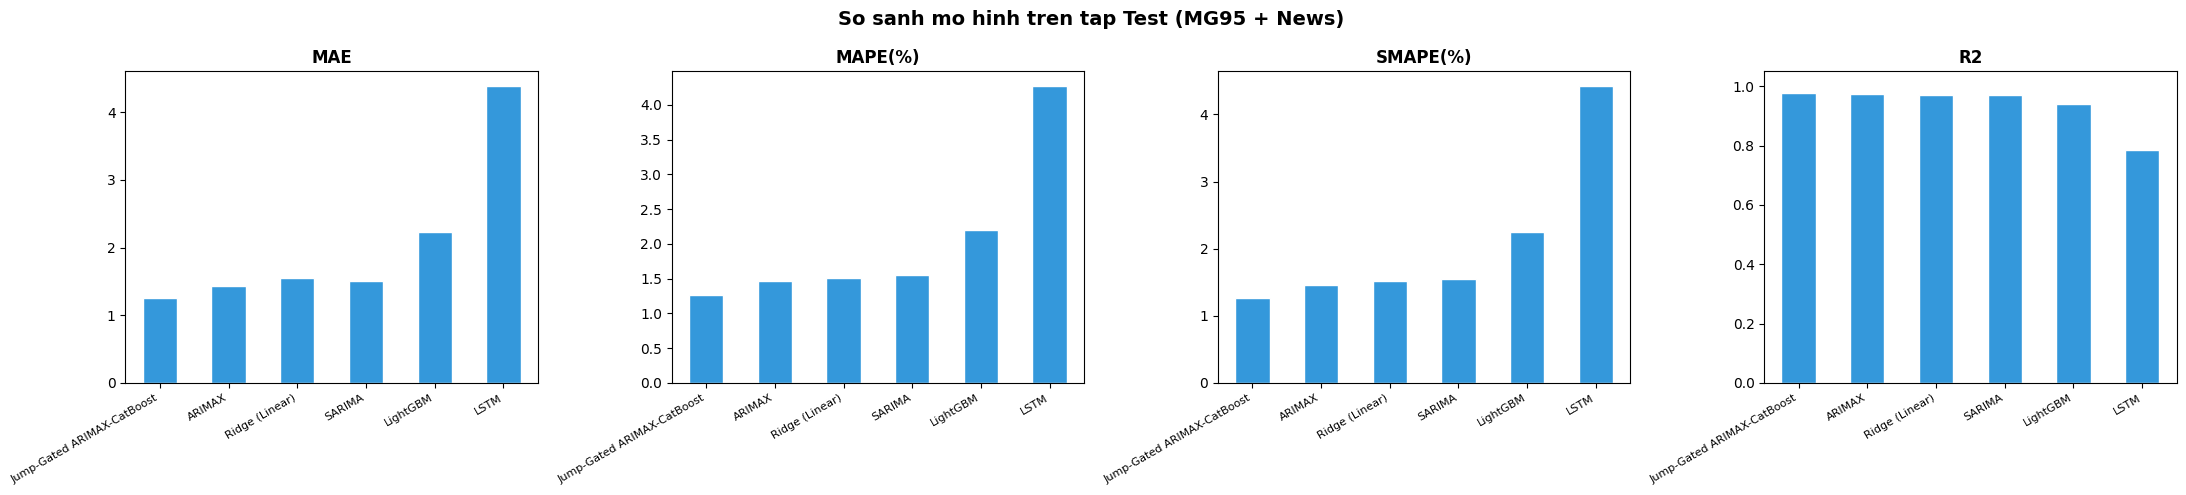

Saved -> results/model_comparison_news.csv + results/charts/model_comparison_news.png


In [13]:
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results).set_index("Model").sort_values("MAPE(%)")
print("=== Regression (test:", test_dates.min().date(), "->", test_dates.max().date(), ") ===")
display(res_df)

(ROOT / "results" / "charts").mkdir(parents=True, exist_ok=True)
res_df.to_csv(ROOT / "results" / "model_comparison_news.csv")

if clf_results:
    print("\n=== Logistic (direction classification) ===")
    display(pd.DataFrame(clf_results).set_index("Model"))

mets = ["MAE", "MAPE(%)", "SMAPE(%)", "R2"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, m in zip(axes, mets):
    vals = res_df[m]
    vals.plot.bar(ax=ax, color="#3498DB", edgecolor="white")
    ax.set_title(m, fontweight="bold"); ax.set_xlabel("")
    ax.set_xticklabels(res_df.index, rotation=30, ha="right", fontsize=8)
    if m == "R2": ax.set_ylim(min(0, vals.min()), 1.05)
plt.suptitle("Model comparison on Test set (MG95 + News)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "results" / "charts" / "model_comparison_news.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> results/model_comparison_news.csv + results/charts/model_comparison_news.png")

## 11. Code Review Results (summary)

**src/ is generally good:** chronological split prevents leakage, RobustScaler fit-on-train, rich feature engineering (lag/MA/ROC/crack-spread/cyclical), Optuna for LightGBM, Walk-Forward + Multi-Horizon.

**Fixed / recommendations:**
- **Added SMAPE** to `evaluation.compute_metrics` (patched) + fixed MAPE to use `abs(y_true)` in the denominator.
- `evaluate_multihorizon` takes `n_train`,`n_val` but does not use them (recomputes 0.8/0.1) — drop the unused params to avoid confusion.
- `build_pipeline`: scaler fit on 80% of **df rows** but split on 80% of **windows** — small boundary mismatch; align the cut point.
- `DOW_sin/cos` divides by 5 (trading week) but data may include weekends — re-check the frequency.
- `make_multihorizon_targets` creates `MG95_H*` columns on df; if called before selecting `feature_cols` it leaks the target — keeping the current order (not called in build_pipeline) is correct.
- DL (iTransformer/GUMNet) uses `Lambda` with tf ops -> hard to serialize when saving; needs a custom layer for `model.save()`.

**Model notes:**
- ARIMAX/SARIMA evaluated one-step-ahead (fair vs ML/DL H=1).
- Logistic Regression is **direction classification** (Accuracy/F1), not price forecasting.
- MG95 is strongly autocorrelated (lag-1), so the linear baseline is already very good; the real value is at longer horizons (H=5,10) and shock periods — change `HORIZON` to check.